# Dynawo & PyPowSyBl: Getting Started Guide

Welcome to the introductory tutorial for dynamic power system simulation using **Dynawo** and **PyPowSyBl**. 
This notebook is designed for new users to understand the complete end-to-end workflow of building, simulating, and analyzing a power grid without the need for complex on-the-fly model compilations.

### Workflow Architecture
0. **Environment Setup:** Download Dynawo and configure the PyPowSyBl link.
1. **Static Topology:** Construct an IIDM (iTesla Internal Data Model) grid programmatically and run a base Load Flow.
2. **Dynamic Mapping:** Link the static components to their corresponding precompiled Modelica differential-algebraic equations (DAE).
3. **Time-Domain Simulation:** Define events (e.g., short-circuits), execute the Dynawo solver, and visualize the transient response.
4. **Small-Signal Stability Analysis:** Extract the linearized state-space representation (Jacobian/A-matrix) from the Dynawo engine to compute eigenvalues.

## Step 0: Environment Setup (Dynawo Install & Config)

Before running dynamic simulations, we need the Dynawo engine installed and configured so PyPowSyBl can find it.
We use Jupyter magic commands to download the latest release securely.

In [1]:
'''
!curl -L $(curl -s -L -X GET https://api.github.com/repos/dynawo/dynawo/releases/latest | grep "Dynawo_Linux" | grep url | cut -d '"' -f 4) -o Dynawo_Linux_latest.zip
!unzip -o Dynawo_Linux_latest.zip > /dev/null 2>&1
!rm Dynawo_Linux_latest.zip 
!./dynawo/dynawo.sh help
'''

'\n!curl -L $(curl -s -L -X GET https://api.github.com/repos/dynawo/dynawo/releases/latest | grep "Dynawo_Linux" | grep url | cut -d \'"\' -f 4) -o Dynawo_Linux_latest.zip\n!unzip -o Dynawo_Linux_latest.zip > /dev/null 2>&1\n!rm Dynawo_Linux_latest.zip \n!./dynawo/dynawo.sh help\n'

In [2]:
CONFIG_DIR="$HOME/.itools"
!mkdir -p "$CONFIG_DIR"
![ -e "$CONFIG_DIR/config.yml" ] && mv "$CONFIG_DIR/config.yml" "$CONFIG_DIR/config_$(date +%Y%m%d_%H%M%S).yml"
!cp ./getting_started_data/config.yml "$CONFIG_DIR/config.yml"
!sed -i "s|WORKING_DIR|$(pwd)|g" "$CONFIG_DIR/config.yml"

print("\nConfiguration successfully mirrored and saved at ~/.itools/config.yml:")
!cat "$CONFIG_DIR/config.yml"


Configuration successfully mirrored and saved at ~/.itools/config.yml:
dynawo:
    homeDir: "/home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Notebook_examples/dynawo"
    debug: true
    debugDir: "/home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Notebook_examples/debugDir"

dynawo-simulation-default-parameters:
    parametersFile: "/home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Notebook_examples/getting_started_data/Base_Case.par"
    network.parametersFile: "/home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Notebook_examples/getting_started_data/Network.par"
    network.parametersId: "Network"
    solver.type: SIM
    solver.parametersFile: "/home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Notebook_examples/getting_started_data/Solver.par"
    solver.parametersId: "Solver"
    debug: true
    debugDir: "/home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Notebook_examples/debugDir"


In [3]:
import os
import numpy as np
import pandas as pd
import pypowsybl as pp
import pypowsybl.dynamic as dyn
import pypowsybl.report as rp
import matplotlib.pyplot as plt
from IPython.display import SVG, display, HTML
from dynawo_notebooks.Scripts.core.visualizer import NetworkVisualizer

# Ensure plots are displayed inline within the Jupyter environment
%matplotlib inline

print(f"PyPowSyBl version: {pp.__version__}")

current_dir = os.getcwd()
dynawo_dir = os.path.join(current_dir, "dynawo")
data_dir = os.path.join(current_dir, "getting_started_data")

PyPowSyBl version: 1.15.0


## Step 1: Constructing the Static Grid (IIDM)

Instead of loading an external file, we will programmatically construct a minimalist 2-bus system. 
This consists of a single synchronous generator supplying a constant impedance load through a transmission line.
After building the topology, we run an initial AC Load Flow to establish the steady-state operating point.

In [4]:
import pypowsybl as pp
import pandas as pd
from IPython.display import display

def create_tutorial_network() -> pp.network.Network:
    """
    Constructs a basic 2-bus static network for educational purposes.
    """
    # Initialize an empty network using the correct PyPowSyBl function
    net = pp.network.load('getting_started_data/Base_Case.xiidm')

    # Create substations and voltage levels
    net.create_substations(id=["SUB_GEN", "SUB_LOAD"], name=["Generator Substation", "Load Substation"])
    net.create_voltage_levels(id=["VL_GEN", "VL_LOAD"],
                              name=["VL_GEN", "VL_LOAD"],
                              substation_id=["SUB_GEN", "SUB_LOAD"],
                              topology_kind=["BUS_BREAKER", "BUS_BREAKER"],
                              nominal_v=[400.0, 400.0])

    # Create buses
    net.create_buses(id=["BUS_GEN", "BUS_LOAD"],
                     name=["BUS_GEN", "BUS_LOAD"],
                     voltage_level_id=["VL_GEN", "VL_LOAD"])

    # Add Generator (acting as Slack bus regulating voltage)
    net.create_generators(id="GEN_1",
                          name="GEN_1",
                          voltage_level_id="VL_GEN",
                          bus_id="BUS_GEN",
                          target_p=150.0,
                          target_v=400.0,
                          min_p=0.0,
                          max_p=300.0,
                          voltage_regulator_on=True)

    # Add Load
    net.create_loads(id="LOAD_1",
                     name="LOAD_1",
                     voltage_level_id="VL_LOAD",
                     bus_id="BUS_LOAD",
                     p0=150.0,
                     q0=50.0)

    # Connect the buses with a transmission line
    net.create_lines(id="LINE_1",
                     name="LINE_1",
                     voltage_level1_id="VL_GEN", bus1_id="BUS_GEN",
                     voltage_level2_id="VL_LOAD", bus2_id="BUS_LOAD",
                     r=1.5, x=15.0, b1=0.0005, b2=0.0005)

    return net

print("Constructing 2-Bus grid...")
network = create_tutorial_network()

# Run an initial AC Load Flow
print("Executing initial AC Load Flow...")
lf_results = pp.loadflow.run_ac(network)

if lf_results[0].status.name == "CONVERGED":
    print("Load Flow Converged Successfully!")
else:
    print(f"Load Flow Failed. Status: {lf_results[0].status.name}")

# Display the resulting buses
display(network.get_buses()[["name", "v_mag", "v_angle"]])

Constructing 2-Bus grid...
Executing initial AC Load Flow...
Load Flow Converged Successfully!


,name,v_mag,v_angle
id,,,
VL_GEN_0,VL_GEN_0,400.000000,0.000000
VL_LOAD_0,VL_LOAD_0,400.528633,-0.820893


## Step 2: Dynamic Model Mapping

With the static Load Flow resolved, we assign differential Modelica models to the static IDs. 
We will use standard, precompiled models that already exist within the default Dynawo directory (`ddb`), safely bypassing any need for on-the-fly compilation.

In [5]:
import pypowsybl.dynamic as dyn

print("Mapping static elements to precompiled dynamic Modelica classes...")
mapping = dyn.ModelMapping()

# 1. Map the Generator to a standard precompiled Dynawo model
df_gen = pd.DataFrame([{
    "static_id": "GEN_1",
    "parameter_set_id": "GEN_1",
    "model_name": "GeneratorSynchronousFourWindingsPmConstVRNordic"
}]).set_index("static_id", drop=False)
mapping.add_synchronous_generator(df_gen)

# 2. Map the Load to a standard Alpha-Beta load model
df_load = pd.DataFrame([{
    "static_id": "LOAD_1",
    "parameter_set_id": "LOAD_1",
    "model_name": "Dynawo.Electrical.Loads.LoadAlphaBeta"
}]).set_index("static_id", drop=False)
mapping.add_base_load(df_load)

print("Dynamic mapping configured successfully.")

Mapping static elements to precompiled dynamic Modelica classes...
Dynamic mapping configured successfully.


## Step 3: Time-Domain Simulation & Plotting

We need to supply the physical parameters for our dynamic models. To do this, we programmatically create standard `.par` XML files.
Crucially, we use `reference` tags to instruct Dynawo to read the steady-state Load Flow values directly from the IIDM network. This prevents algebraic solver errors upon initialization.

After generating the parameters, we inject a short-circuit fault at the load bus and run the simulation.

In [6]:
import pypowsybl.report as rp
import pypowsybl.dynamic as dyn
import matplotlib.pyplot as plt
import os

# Ensure plots display inline in the notebook
%matplotlib inline

print("Generating dynamic parameter files (.par)...")

# 1. Generator Parameters (Base_Case.par)
# ADVANCED MATH FIX: 
# 1. UseApproximation is "true" to balance 84 variables = 84 equations.
# 2. limitsAtInit set to "false" so KINSOL can find the steady-state freely at t=0.
# 3. md and mq are given non-zero values to avoid approximation curve singularities.
xml_base_case = '''<?xml version="1.0" encoding="UTF-8"?>
<parametersSet xmlns="http://www.rte-france.com/dynawo">
    <set id="GEN_1">
        <!-- Mechanical & Nominal Parameters -->
        <par type="DOUBLE" name="generator_H" value="3.0"/>
        <par type="DOUBLE" name="generator_DPu" value="0.0"/>
        <par type="DOUBLE" name="generator_PNomAlt" value="500.0"/>
        <par type="DOUBLE" name="generator_PNomTurb" value="500.0"/>
        <par type="DOUBLE" name="generator_SNom" value="800.0"/>
        <par type="DOUBLE" name="generator_SnTfo" value="800.0"/>
        <par type="DOUBLE" name="generator_UBaseHV" value="400.0"/>
        <par type="DOUBLE" name="generator_UBaseLV" value="400.0"/>
        <par type="DOUBLE" name="generator_UNom" value="400.0"/>
        <par type="DOUBLE" name="generator_UNomHV" value="400.0"/>
        <par type="DOUBLE" name="generator_UNomLV" value="400.0"/>

        <!-- Reactances & Resistances -->
        <par type="DOUBLE" name="generator_RaPu" value="0.002"/>
        <par type="DOUBLE" name="generator_RsPu" value="0.005"/>
        <par type="DOUBLE" name="generator_XdPu" value="1.8"/>
        <par type="DOUBLE" name="generator_XqPu" value="1.7"/>
        <par type="DOUBLE" name="generator_XpdPu" value="0.3"/>
        <par type="DOUBLE" name="generator_XppdPu" value="0.2"/>
        <par type="DOUBLE" name="generator_XppqPu" value="0.2"/>
        <par type="DOUBLE" name="generator_XpqPu" value="0.3"/>
        <par type="DOUBLE" name="generator_XlPu" value="0.15"/>
        <par type="DOUBLE" name="generator_XTfPu" value="0.15"/>
        <par type="DOUBLE" name="generator_RTfPu" value="0.0"/>

        <!-- Time Constants -->
        <par type="DOUBLE" name="generator_Tpd0" value="6.0"/>
        <par type="DOUBLE" name="generator_Tpq0" value="0.5"/>
        <par type="DOUBLE" name="generator_Tppd0" value="0.05"/>
        <par type="DOUBLE" name="generator_Tppq0" value="0.05"/>

        <!-- Excitation & Miscellaneous -->
        <par type="INT" name="generator_ExcitationPu" value="1"/>
        <par type="DOUBLE" name="generator_MdPuEfd" value="1.0"/>
        <par type="BOOL" name="generator_UseApproximation" value="true"/>
        
        <!-- Saturation parameters (Non-zero to avoid math singularities) -->
        <par type="DOUBLE" name="generator_md" value="0.1"/>
        <par type="DOUBLE" name="generator_mq" value="0.05"/>
        <par type="DOUBLE" name="generator_nd" value="1.0"/>
        <par type="DOUBLE" name="generator_nq" value="1.0"/>
        
        <!-- Default Overrides (Ensuring strict compliance) -->
        <par type="INT" name="generator_NbSwitchOffSignals" value="3"/>
        <par type="INT" name="generator_State0" value="2"/>
        <par type="BOOL" name="generator_SwitchOffSignal10" value="false"/>
        <par type="BOOL" name="generator_SwitchOffSignal20" value="false"/>
        <par type="BOOL" name="generator_SwitchOffSignal30" value="false"/>
        <par type="DOUBLE" name="generator_iStart0Pu_im" value="0.0"/>
        <par type="DOUBLE" name="generator_iStart0Pu_re" value="0.0"/>

        <!-- Voltage Regulator Parameters -->
        <par type="DOUBLE" name="voltageRegulator_EfdMaxPu" value="10.0"/>
        <par type="DOUBLE" name="voltageRegulator_IrLimPu" value="99.0"/>
        <par type="DOUBLE" name="voltageRegulator_KPss" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_KTgr" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_OelMode" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_tDerOmega" value="1.0"/>
        <par type="DOUBLE" name="voltageRegulator_tLagPss" value="0.1"/>
        <par type="DOUBLE" name="voltageRegulator_tLagTgr" value="0.1"/>
        <par type="DOUBLE" name="voltageRegulator_tLeadPss" value="0.1"/>
        <par type="DOUBLE" name="voltageRegulator_tLeadTgr" value="0.1"/>
        <par type="DOUBLE" name="voltageRegulator_tOelMin" value="10.0"/>
        <par type="DOUBLE" name="voltageRegulator_add_k1" value="1.0"/>
        <par type="DOUBLE" name="voltageRegulator_add_k2" value="1.0"/>
        <par type="DOUBLE" name="voltageRegulator_const_k" value="1.0"/>
        <par type="INT" name="voltageRegulator_derivative_initType" value="1"/>
        <par type="DOUBLE" name="voltageRegulator_derivative_x_start" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_derivative_y_start" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_gain1_k" value="1.0"/>
        <par type="DOUBLE" name="voltageRegulator_gain_k" value="10.0"/>
        <par type="DOUBLE" name="voltageRegulator_greaterEqualThreshold_threshold" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag1_a_1_" value="1.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag1_b_1_" value="1.0"/>
        <par type="INT" name="voltageRegulator_leadLag1_na" value="2"/>
        <par type="INT" name="voltageRegulator_leadLag1_nb" value="2"/>
        <par type="INT" name="voltageRegulator_leadLag1_nx" value="1"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag1_x_start_0_" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag1_y_start" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag2_a_1_" value="1.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag2_b_1_" value="1.0"/>
        <par type="INT" name="voltageRegulator_leadLag2_na" value="2"/>
        <par type="INT" name="voltageRegulator_leadLag2_nb" value="2"/>
        <par type="INT" name="voltageRegulator_leadLag2_nx" value="1"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag2_x_start_0_" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag2_y_start" value="0.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag_a_1_" value="1.0"/>
        <par type="DOUBLE" name="voltageRegulator_leadLag_b_1_" value="1.0"/>
        <par type="INT" name="voltageRegulator_leadLag_na" value="2"/>
        <par type="INT" name="voltageRegulator_leadLag_nb" value="2"/>
        <par type="INT" name="voltageRegulator_leadLag_nx" value="1"/>
        <par type="INT" name="voltageRegulator_limIntegrator_initType" value="3"/>
        <par type="DOUBLE" name="voltageRegulator_limIntegrator_k" value="1.0"/>
        
        <!-- FIX: Disable limits at initialization for KINSOL convergence -->
        <par type="BOOL" name="voltageRegulator_limIntegrator_limitsAtInit" value="false"/>
        <par type="DOUBLE" name="voltageRegulator_limIntegrator_outMin" value="-10.0"/>
        <par type="BOOL" name="voltageRegulator_limIntegrator_strict" value="false"/>
        <par type="BOOL" name="voltageRegulator_limIntegrator_use_reset" value="false"/>
        <par type="BOOL" name="voltageRegulator_limIntegrator_use_set" value="false"/>
        <par type="INT" name="voltageRegulator_limiter_homotopyType" value="1"/>
        
        <!-- FIX: Disable limits at initialization for KINSOL convergence -->
        <par type="BOOL" name="voltageRegulator_limiter_limitsAtInit" value="false"/>
        <par type="BOOL" name="voltageRegulator_limiter_strict" value="false"/>
        <par type="DOUBLE" name="voltageRegulator_limiter_uMax" value="10.0"/>
        <par type="DOUBLE" name="voltageRegulator_overExcitationLimitation_Y0" value="-1.0"/>
        <par type="INT" name="voltageRegulator_timer_initType" value="3"/>
        <par type="DOUBLE" name="voltageRegulator_timer_k" value="1.0"/>
        
        <!-- FIX: Disable limits at initialization for KINSOL convergence -->
        <par type="BOOL" name="voltageRegulator_timer_limitsAtInit" value="false"/>
        <par type="DOUBLE" name="voltageRegulator_timer_outMax" value="99.0"/>
        <par type="BOOL" name="voltageRegulator_timer_strict" value="false"/>
        <par type="BOOL" name="voltageRegulator_timer_use_reset" value="false"/>
        <par type="BOOL" name="voltageRegulator_timer_use_set" value="false"/>

        <!-- IIDM References for proper steady-state initialization -->
        <reference type="DOUBLE" name="generator_P0Pu" origData="IIDM" origName="p_pu"/>
        <reference type="DOUBLE" name="generator_Q0Pu" origData="IIDM" origName="q_pu"/>
        <reference type="DOUBLE" name="generator_U0Pu" origData="IIDM" origName="v_pu"/>
        <reference type="DOUBLE" name="generator_UPhase0" origData="IIDM" origName="angle"/>
    </set>
</parametersSet>
'''

# 2. Network Parameters (Network.par)
xml_network = '''<?xml version="1.0" encoding="UTF-8"?>
<parametersSet xmlns="http://www.rte-france.com/dynawo">
    <set id="Network">
        <par type="DOUBLE" name="load_alpha" value="1.0"/>
        <par type="DOUBLE" name="load_beta" value="2.0"/>
        <par type="DOUBLE" name="load_Tp" value="90"/>
        <par type="DOUBLE" name="load_Tq" value="90"/>
        <par type="DOUBLE" name="load_alphaLong" value="0.0"/>
        <par type="DOUBLE" name="load_betaLong" value="0.0"/>
        <par type="BOOL" name="load_isControllable" value="false"/>
        <par type="BOOL" name="load_isRestorative" value="false"/>
        <par type="DOUBLE" name="load_zPMax" value="100.0"/>
        <par type="DOUBLE" name="load_zQMax" value="100.0"/>
        <par type="BOOL" name="BUS_LOAD_hasShortCircuitCapabilities" value="true"/>
    </set>
    <set id="LOAD_1">
        <par type="DOUBLE" name="load_alpha" value="1.0"/>
        <par type="DOUBLE" name="load_beta" value="2.0"/>
        <par type="DOUBLE" name="load_Tp" value="90"/>
        <par type="DOUBLE" name="load_Tq" value="90"/>
        <par type="DOUBLE" name="load_alphaLong" value="0.0"/>
        <par type="DOUBLE" name="load_betaLong" value="0.0"/>
        <par type="BOOL" name="load_isControllable" value="false"/>
        <par type="BOOL" name="load_isRestorative" value="false"/>
        <par type="DOUBLE" name="load_zPMax" value="100.0"/>
        <par type="DOUBLE" name="load_zQMax" value="100.0"/>
    </set>
</parametersSet>
'''

# 3. Create Solver parameter file (Solver.par)
xml_solver = '''<?xml version="1.0" encoding="UTF-8"?>
<parametersSet xmlns="http://www.rte-france.com/dynawo">
    <set id="Solver">
        <par type="BOOL" name="enableSilentZ" value="true"/>
        <par type="DOUBLE" name="fnormtol" value="1e-3"/>
        <par type="DOUBLE" name="fnormtolAlg" value="1e-3"/>
        <par type="DOUBLE" name="fnormtolAlgInit" value="1e-3"/>
        <par type="DOUBLE" name="fnormtolAlgJ" value="1e-3"/>
        <par type="DOUBLE" name="hMax" value="2.0"/>
        <par type="DOUBLE" name="hMin" value="1.0E-6"/>
        <par type="DOUBLE" name="initialaddtol" value="1"/>
        <par type="DOUBLE" name="initialaddtolAlg" value="1"/>
        <par type="DOUBLE" name="initialaddtolAlgInit" value="1"/>
        <par type="DOUBLE" name="initialaddtolAlgJ" value="1"/>
        <par type="DOUBLE" name="kReduceStep" value="0.5"/>
        <par type="INT" name="maxNewtonTry" value="10"/>
        <par type="INT" name="maximumNumberSlowStepIncrease" value="40"/>
        <par type="DOUBLE" name="minimalAcceptableStep" value="1.0"/>
        <par type="STRING" name="minimumModeChangeTypeForAlgebraicRestoration" value="ALGEBRAIC_J_UPDATE"/>
        <par type="INT" name="msbset" value="0"/>
        <par type="INT" name="msbsetAlg" value="5"/>
        <par type="INT" name="msbsetAlgInit" value="1"/>
        <par type="INT" name="msbsetAlgJ" value="1"/>
        <par type="INT" name="mxiter" value="15"/>
        <par type="INT" name="mxiterAlg" value="30"/>
        <par type="INT" name="mxiterAlgInit" value="50"/>
        <par type="INT" name="mxiterAlgJ" value="50"/>
        <par type="DOUBLE" name="mxnewtstep" value="100000"/>
        <par type="DOUBLE" name="mxnewtstepAlg" value="100000"/>
        <par type="DOUBLE" name="mxnewtstepAlgInit" value="100000"/>
        <par type="DOUBLE" name="mxnewtstepAlgJ" value="100000"/>
        <par type="BOOL" name="optimizeAlgebraicResidualsEvaluations" value="true"/>
        <par type="BOOL" name="optimizeReinitAlgebraicResidualsEvaluations" value="true"/>
        <par type="INT" name="printfl" value="0"/>
        <par type="INT" name="printflAlg" value="0"/>
        <par type="INT" name="printflAlgInit" value="0"/>
        <par type="INT" name="printflAlgJ" value="0"/>
        <par type="DOUBLE" name="scsteptol" value="1e-3"/>
        <par type="DOUBLE" name="scsteptolAlg" value="1e-3"/>
        <par type="DOUBLE" name="scsteptolAlgInit" value="1e-3"/>
        <par type="DOUBLE" name="scsteptolAlgJ" value="1e-3"/>
        <par type="BOOL" name="skipNRIfInitialGuessOK" value="true"/>
    </set>
</parametersSet>
'''

# Write XML files to the data directory
data_dir = "getting_started_data"
os.makedirs(data_dir, exist_ok=True)

with open(os.path.join(data_dir, "Base_Case.par"), "w") as f:
    f.write(xml_base_case)
with open(os.path.join(data_dir, "Network.par"), "w") as f:
    f.write(xml_network)
with open(os.path.join(data_dir, "Solver.par"), "w") as f:
    f.write(xml_solver)

print("Parameters saved successfully.")

# 4. Configure Events (Short-circuit fault at LOAD bus)
print("Configuring short-circuit event...")
events = dyn.EventMapping()
events.add_node_fault(
    static_id="BUS_LOAD",
    start_time=2.0,
    fault_time=0.1,
    r_pu=0.0,
    x_pu=0.0001
)

# 5. Track Output Variables (Generator Rotor Angle & Load Voltage)
outputs = dyn.OutputVariableMapping()
outputs.add_curves("GEN_1", ["generator_theta"])
outputs.add_standard_model_curves("BUS_LOAD", "U_value")

# Ensure the debugging directory is created
debug_dir_path = os.path.join(os.getcwd(), "debugDir")
os.makedirs(debug_dir_path, exist_ok=True)

sim_parameters = dyn.Parameters(
    start_time=0.0, 
    stop_time=10.0,
    provider_parameters={
        "debug": "true",
        "debugDir": debug_dir_path
    }
)

report_node = rp.Reporter()

print("Running transient simulation via Dynawo...")
simulation = dyn.Simulation()

results = simulation.run(
    network,
    model_mapping=mapping,
    event_mapping=events,
    timeseries_mapping=outputs,
    parameters=sim_parameters,
    report_node=report_node
)

# Automated Results / Debugging Logic
if results.status().name == 'SUCCESS':
    print("Simulation Completed Successfully!")
    curves = results.curves()

    plt.figure(figsize=(10, 5))
    plt.plot(curves["time"], curves["GEN_1_generator_theta"], label="Generator Rotor Angle (rad)")
    plt.title("Rotor Angle Transient Response during Short-Circuit")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (rad)")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print(f"\nSimulation failed: {results.status_text()}")
    print("\n" + "="*50)
    print("DYNAWO INTERNAL LOG ANALYSIS")
    print("="*50)
    
    if os.path.exists(debug_dir_path):
        subdirs = [os.path.join(debug_dir_path, d) for d in os.listdir(debug_dir_path) if os.path.isdir(os.path.join(debug_dir_path, d))]
        if subdirs:
            latest_subdir = max(subdirs, key=os.path.getmtime)
            log_file = os.path.join(latest_subdir, "dynawo.log")
            
            if os.path.exists(log_file):
                with open(log_file, "r", encoding="utf-8") as f:
                    lines = f.readlines()
                    print(f"Reading the last 25 lines from: {log_file}\n")
                    print("".join(lines[-25:]))
            else:
                print(f"Could not find 'dynawo.log' inside {latest_subdir}")
        else:
            print("No execution folders found inside debugDir. The simulation crashed before writing logs.")
    else:
        print("debugDir not found even after forcing creation. Check folder write permissions.")

Generating dynamic parameter files (.par)...
Parameters saved successfully.
Configuring short-circuit event...
Running transient simulation via Dynawo...

Simulation failed: KINSOL fails to solve the problem ( DYNSolverKINAlgRestoration.cpp:394 )

DYNAWO INTERNAL LOG ANALYSIS
No execution folders found inside debugDir. The simulation crashed before writing logs.


## Step 4: Small-Signal Stability Analysis (Eigenvalues)

Dynawo operates fundamentally as a state-space engine. By configuring specific provider parameters, we can force the C++ backend to extract the linearized system matrix (`A-matrix` or Jacobian) at the initialized operating point.

We then utilize Python's scientific ecosystem (`numpy.linalg`) to compute the eigenvalues, revealing the system's oscillatory modes and damping ratios.

Configuring Dynawo to extract the Linear Model (A-matrix)...
Running initialization to extract A-matrix...
Loading linearized state-space matrix (A-matrix)...
Computing eigenvalues...


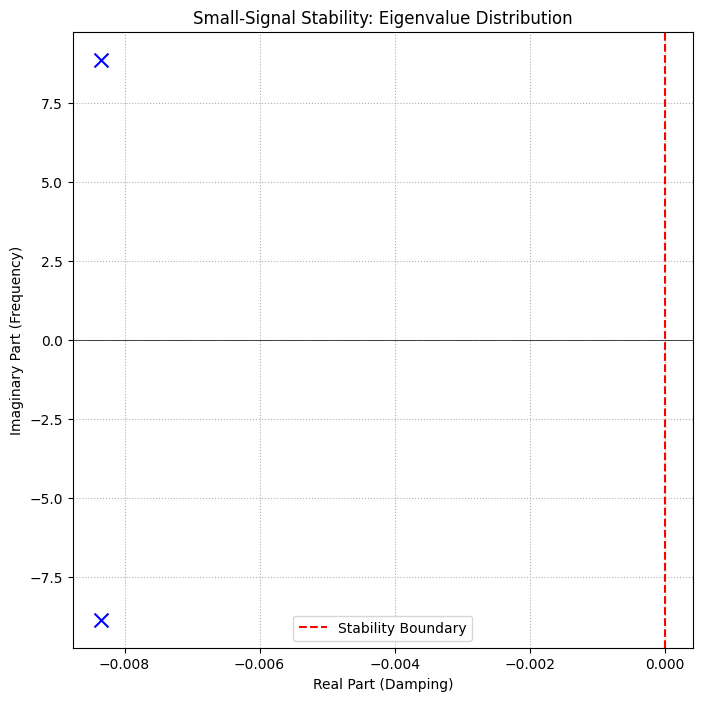

System is STRICTLY STABLE (All poles in the left-hand plane).


In [7]:
import numpy as np

print("Configuring Dynawo to extract the Linear Model (A-matrix)...")

# Add parameters to extract the linear model
# A 0-second simulation is enough to get the steady-state Jacobian
sim_parameters_linear = dyn.Parameters(
    start_time=0.0,
    stop_time=1.0, 
    provider_parameters={"extractLinearModel": "true", "linearModelOutFile": "A_matrix.csv"}
)

print("Running initialization to extract A-matrix...")
results_lin = simulation.run(
    network,
    model_mapping=mapping,
    event_mapping=dyn.EventMapping(), # No events needed for small-signal
    timeseries_mapping=outputs,
    parameters=sim_parameters_linear,
    report_node=report_node
)

matrix_filepath = os.path.join(current_dir, "A_matrix.csv")

if os.path.exists(matrix_filepath):
    print("Loading linearized state-space matrix (A-matrix)...")
    a_matrix = pd.read_csv(matrix_filepath, header=None).values

    print("Computing eigenvalues...")
    eigenvalues = np.linalg.eigvals(a_matrix)

    real_parts = np.real(eigenvalues)
    imag_parts = np.imag(eigenvalues)

    # Plotting the Root Locus on the Complex Plane
    plt.figure(figsize=(8, 8))
    plt.scatter(real_parts, imag_parts, color='blue', marker='x', s=100)
    plt.axvline(x=0, color='red', linestyle='--', label='Stability Boundary')
    plt.axhline(y=0, color='black', linewidth=0.5)
    plt.title("Small-Signal Stability: Eigenvalue Distribution")
    plt.xlabel("Real Part (Damping)")
    plt.ylabel("Imaginary Part (Frequency)")
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()

    unstable_modes = np.sum(real_parts > 0)
    if unstable_modes == 0:
        print("System is STRICTLY STABLE (All poles in the left-hand plane).")
    else:
        print(f"WARNING: System is UNSTABLE. Detected {unstable_modes} poles in the right-hand plane.")
else:
    print("Matrix file not found. Ensure Dynawo completed the extraction successfully.")